# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm
import sys
from pathlib import Path

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1551 # [nm]
light_lam = 1551 # [nm]

In [ ]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
chip.turn_off()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('crosstalks', verbose=True)



Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-07-17_602833e/1_rms_lam1551
Archive created at /mnt/disk1/archive/2026-07-17_602833e/2_test_reboot


In [4]:
phobos.Config().set('dm.stabilization_time', 0.002, autosave=False)
phobos.Config().set('photonic_chip.stabilization_time', 0.003, autosave=False)

In [5]:
phobos.Config().get('photonic_chip.stabilization_time')

0.003

# Check cropping

✅ Cred3 reset to configuration defaults.


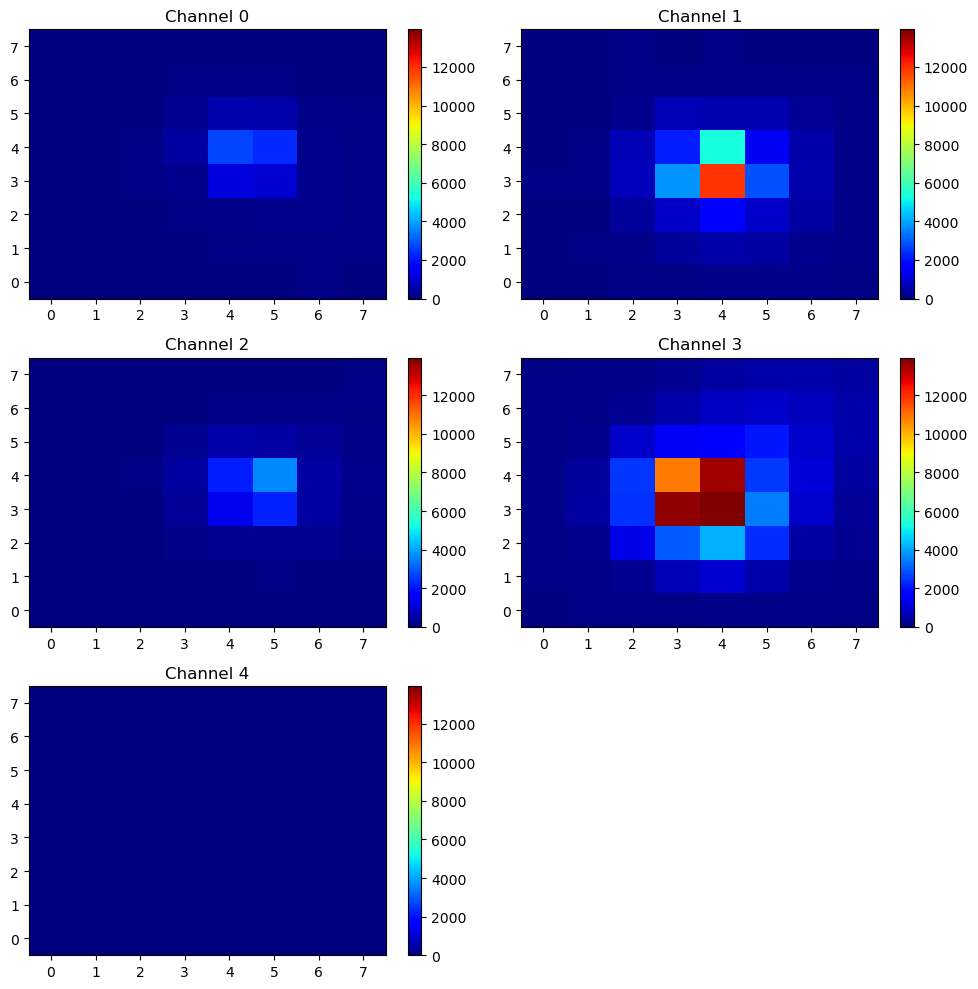

In [5]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode='centers')

# Calibration injection

In [6]:
# Injection calibration
inj = phobos.Injection()


In [ ]:
# inj.zero()
# maps = inj.get_injection_maps(verbose=True)
# inj.zero()

# fig = plt.figure(figsize=(10,10))
# for i in range(4):
#     image = maps[0][i]
#     tip_range = tilt_ramp = maps[1]
#     tilt_step = np.diff(tilt_ramp)[0]
#     tip_step = np.diff(tip_range)[0]
#     plt.subplot(2,2,i+1)
#     plt.imshow(image, origin='lower', cmap='jet',
#             extent=[tilt_ramp.min()-tilt_step/2, tilt_ramp.max()+tilt_step/2,
#                     tip_range.min()-tip_step/2, tip_range.max()+tip_step/2],
#             vmin=maps[0].min(),
#             vmax=maps[0].max())
#     plt.colorbar()
#     plt.xlabel('Tilt (mrad)')
#     plt.ylabel('Tip (mrad)')
# plt.tight_layout()

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:17<00:51, 17.28s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:34<00:35, 17.50s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:56<00:19, 19.23s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:16<00:00, 19.03s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69033,0.74896) mrad
Injection spread of seg=137: (tip, tilt) = (0.72071,0.75982) mrad
Injection spread of seg=136: (tip, tilt) = (0.71484,0.74510) mrad
Injection spread of seg=135: (tip, tilt) = (0.73390,0.77563) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.36901,-0.13733) mrad; flux = 856.5
Injection max of seg=137: (tip, tilt) = (-0.07680,-0.24236) mrad; flux = 832.5
Injection max of seg=136: (tip, tilt) = (0.28760,-0.32723) mrad; flux = 706.1
Injection max of seg=135: (tip, tilt) = (0.44582,-0.32742) mrad; flux = 624.4
✅ Injection calibration saved to config (injection.max)


Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


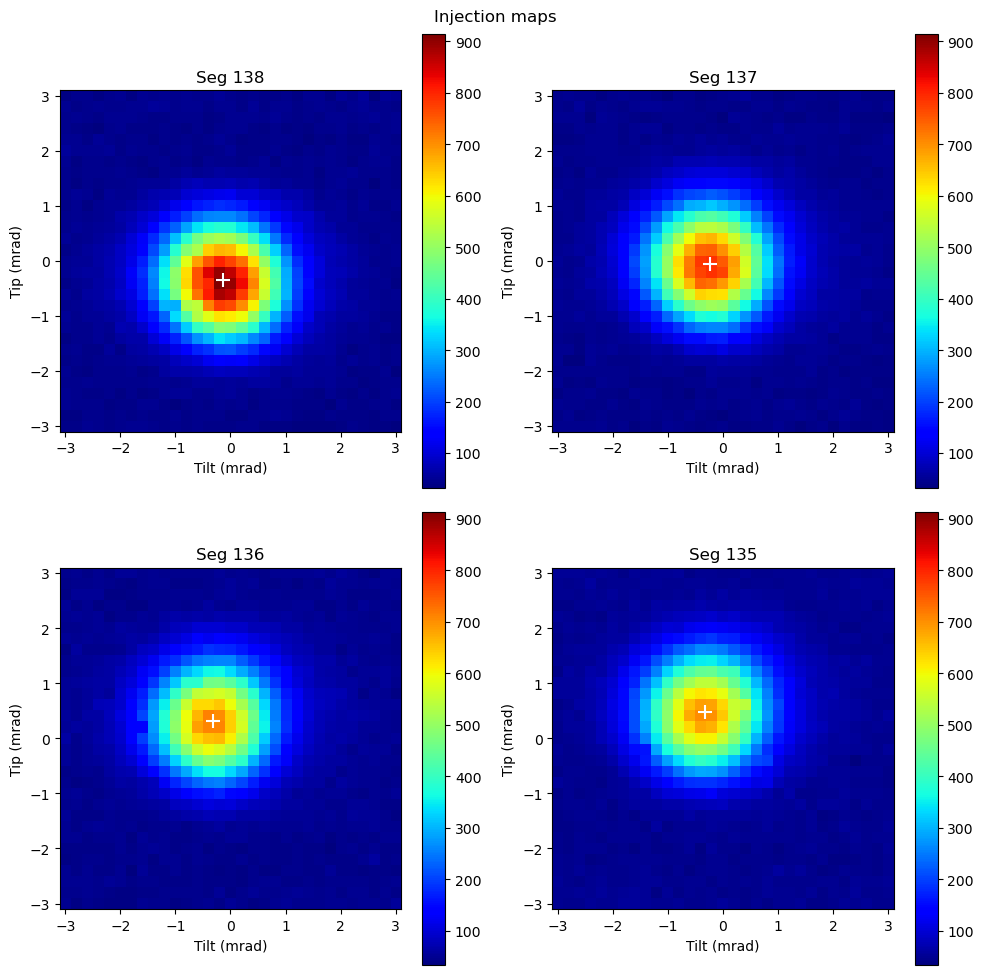

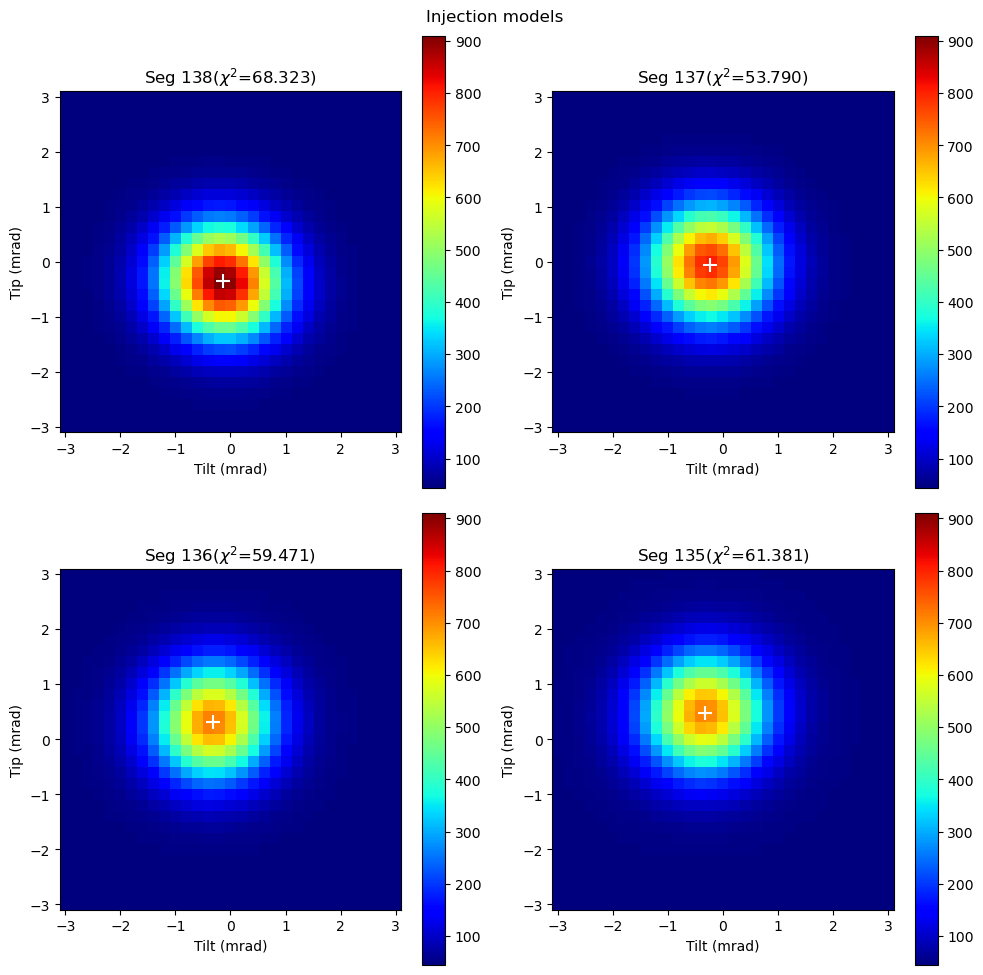

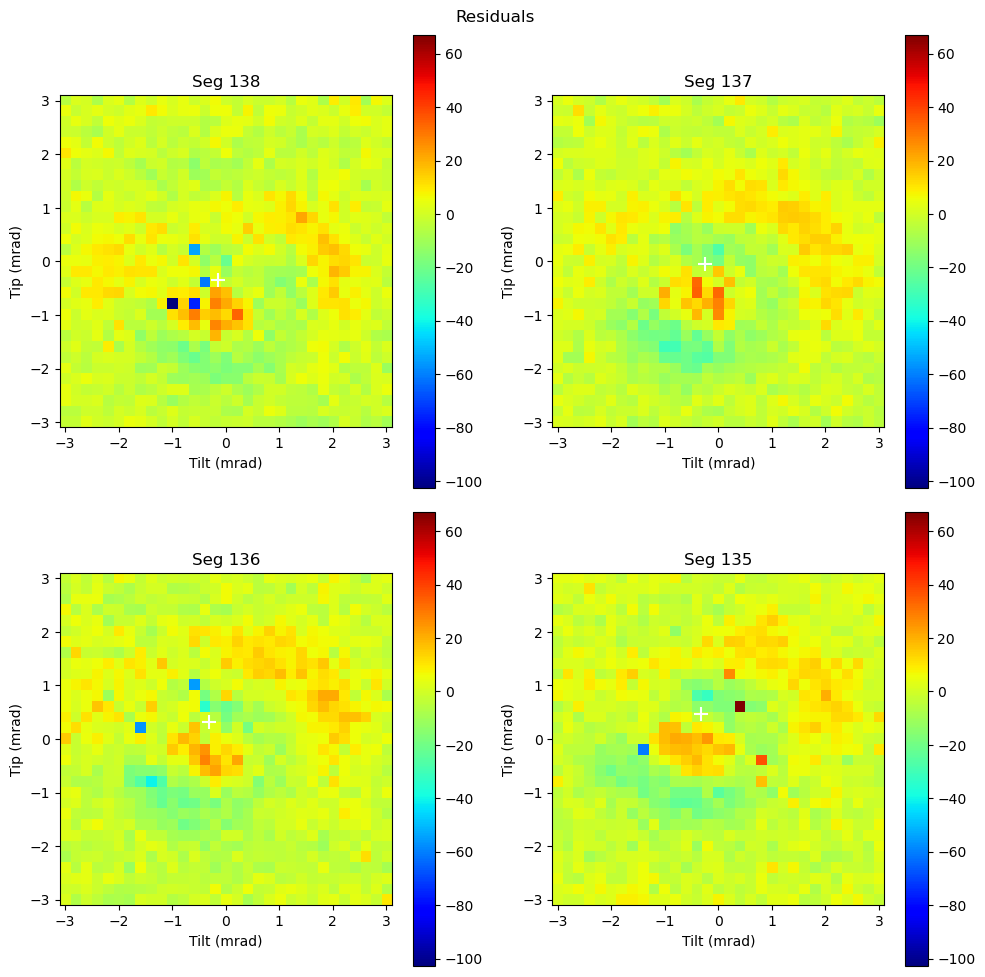

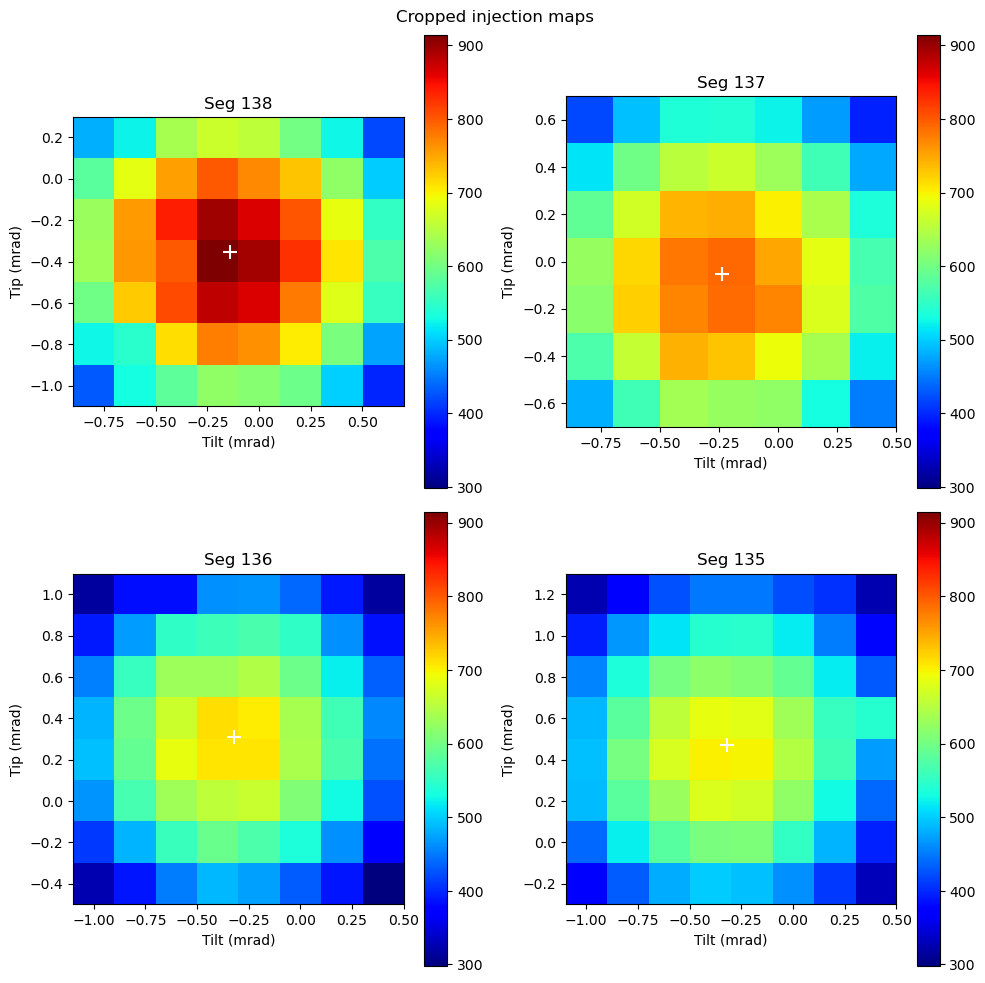

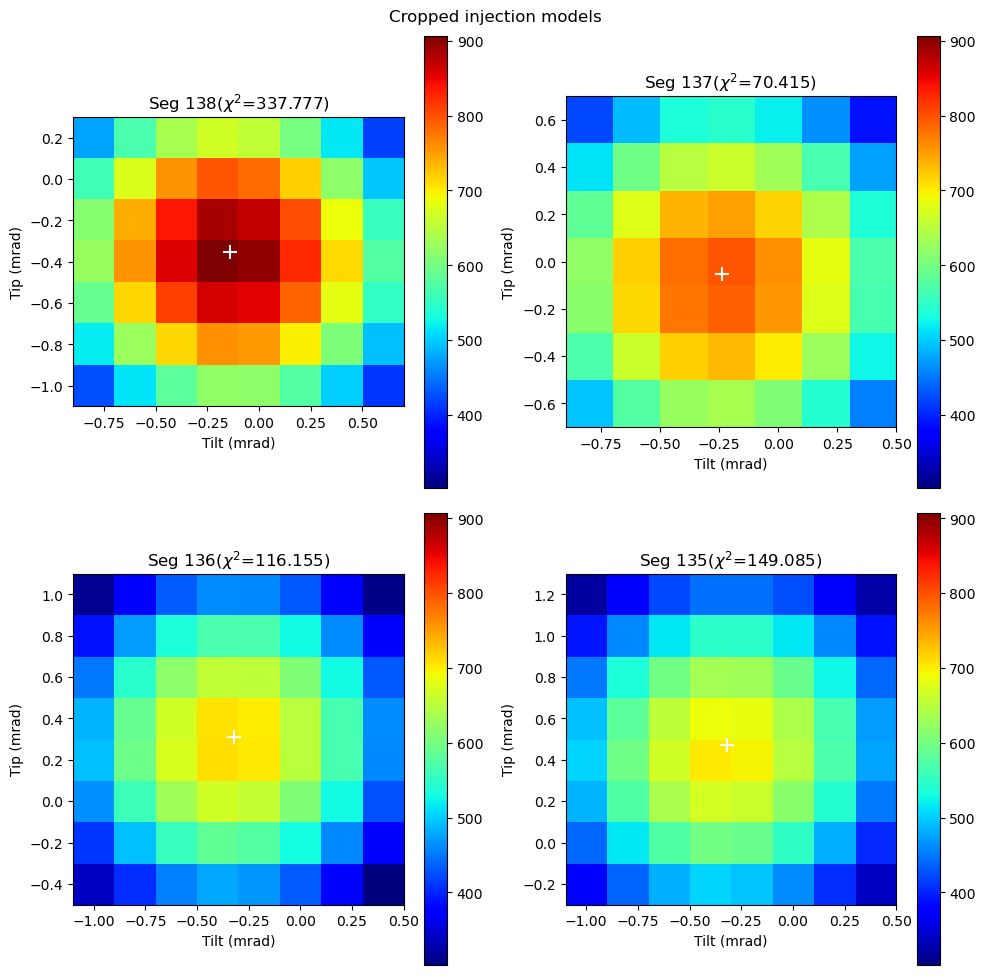

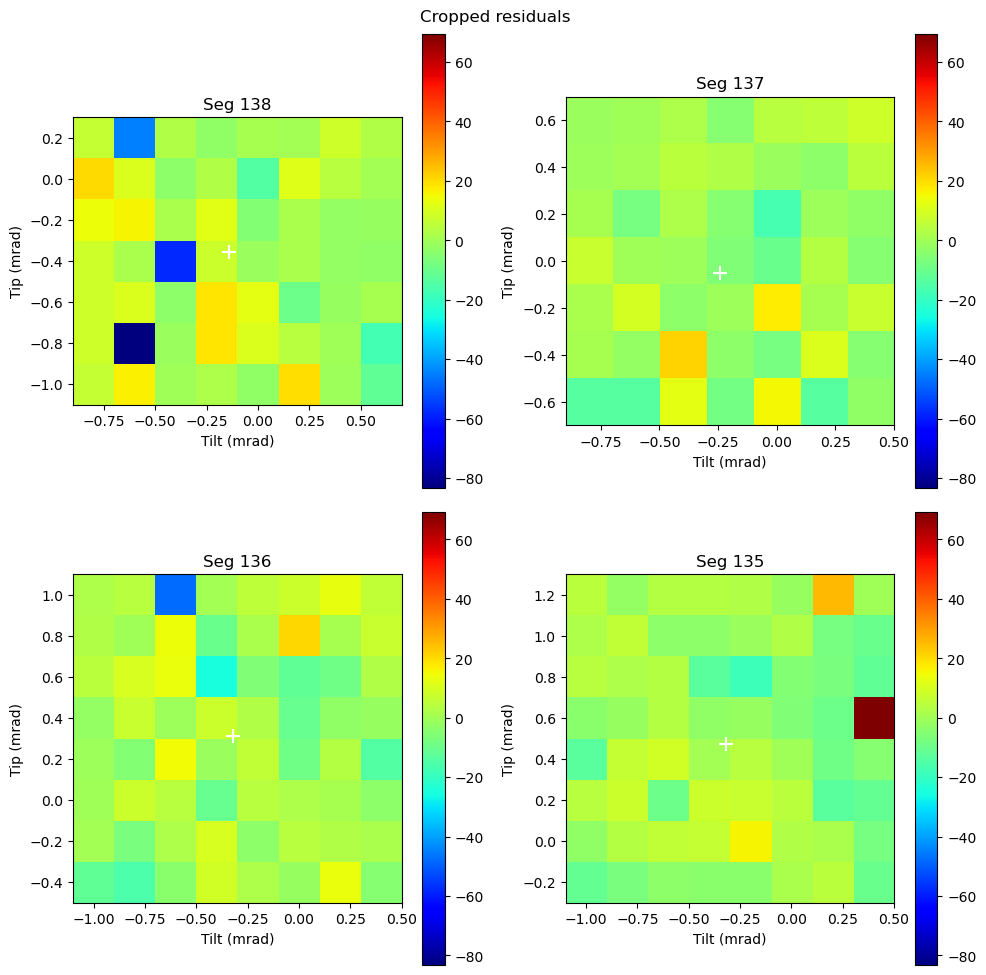

In [7]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3, no_balancing=True)

inj.zero()

# Phase shifter calibration

Injection MAX on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
  - Scanning shifter 17...
  ✅ Shifter 17 calibrated: Period=0.5996 W -> Coeff=0.0954 W/rad
  - Scanning shifter 18...
  ✅ Shifter 18 calibrated: Period=0.5991 W -> Coeff=0.0954 W/rad
  - Scanning shifter 19...
  ✅ Shifter 19 calibrated: Period=0.5954 W -> Coeff=0.0948 W/rad
  - Scanning shifter 20...
  ✅ Shifter 20 calibrated: Period=0.5849 W -> Coeff=0.0931 W/rad


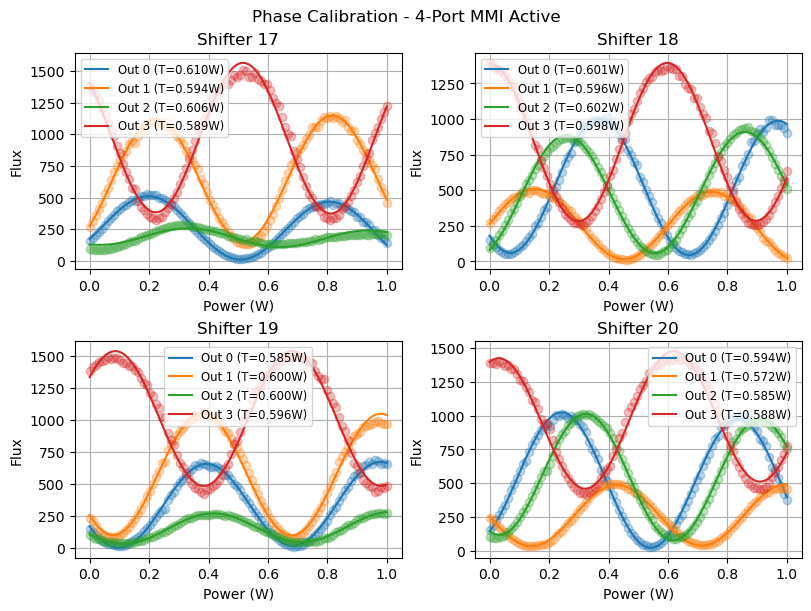

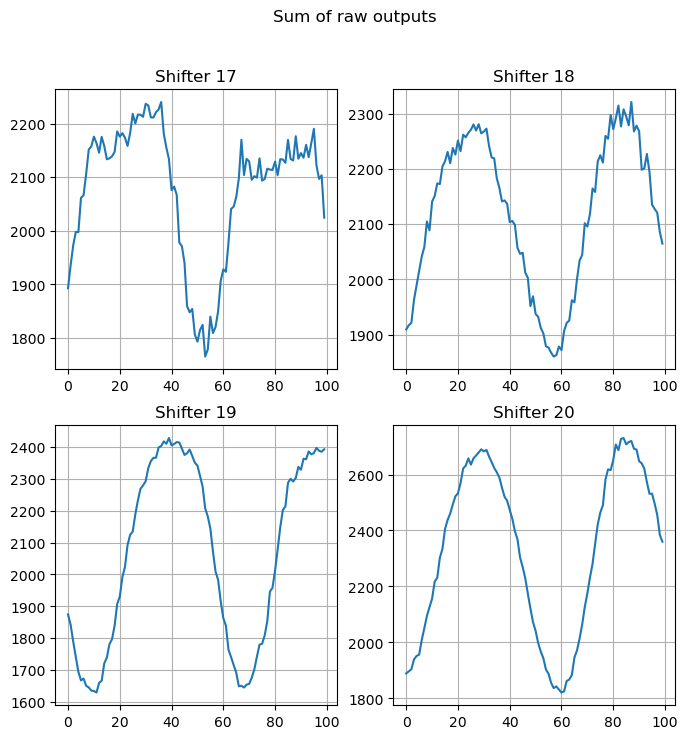

In [8]:
inj.set_max()

avg_frames = 5
# TOPAs calibration
chip_coeffs, chip_scans, chip_power_range = chip.phase_calibration(plot=True, verbose=False, crop_mode='centers', nroi=4)

np.save(path / "chip_coeffs.npy", chip_coeffs)
np.savez(path / "chip_scans.npz", chip_scans=chip_scans, chip_power_range=chip_power_range)

s = chip_scans[:,:,::-1].sum(2)
plt.figure(figsize=(8,8))
plt.suptitle("Sum of raw outputs")
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(s[i].T)
    plt.grid()
    plt.title(f"Shifter {chip.shifters[i].channel}")

chip.turn_off()
    

# Mono-beam scan

In [ ]:
def scan_monobeam(inj_mode, n_ch, n_roi, piston_range):
    all_beams_flux = []
    for beam in range(n_ch):
        inj.off()
        inj_mode(beam)

        ref_tip = dm[inj_seg[beam]].get_tip()
        ref_tilt = dm[inj_seg[beam]].get_tilt()

        outs = np.empty((len(piston_range), n_roi))
        for p, opd in enumerate(piston_range):
            dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
            outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames, crop_mode='centers')[:n_roi]
        all_beams_flux.append(outs)
    all_beams_flux = np.array(all_beams_flux)

    return all_beams_flux

## Balanced positions

In [ ]:
n_roi = 4
avg_frames = 10
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
filename = 'crosstalk_dm_scan_max'

balanced_all_beams = scan_monobeam(inj.set_balanced, n_ch, n_roi, piston_range)
np.savez(path / filename, flux=balanced_all_beams, piston_range=piston_range, lam=lam)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for beam in range(n_ch):
    for o in range(n_roi):
        axs[beam].plot(piston_range / (lam/2), balanced_all_beams[beam, :, o], color=colors[o], linestyle='-', label=f'Output {o}')
        axs[beam].plot(piston_range / (lam/2), balanced_all_beams[beam].mean(1), color='k', linestyle='-', label=f'Mean')
    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()

fig.tight_layout()
fig.savefig(path / filename, format='png', dpi=150)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(n_ch):
    axs.plot(piston_range / (lam/2), balanced_all_beams[beam].sum(1), 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
filename2 = filename + '_totalflux.png'
fig.savefig(path / filename2, format='png', dpi=150)

inj.set_balanced()

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


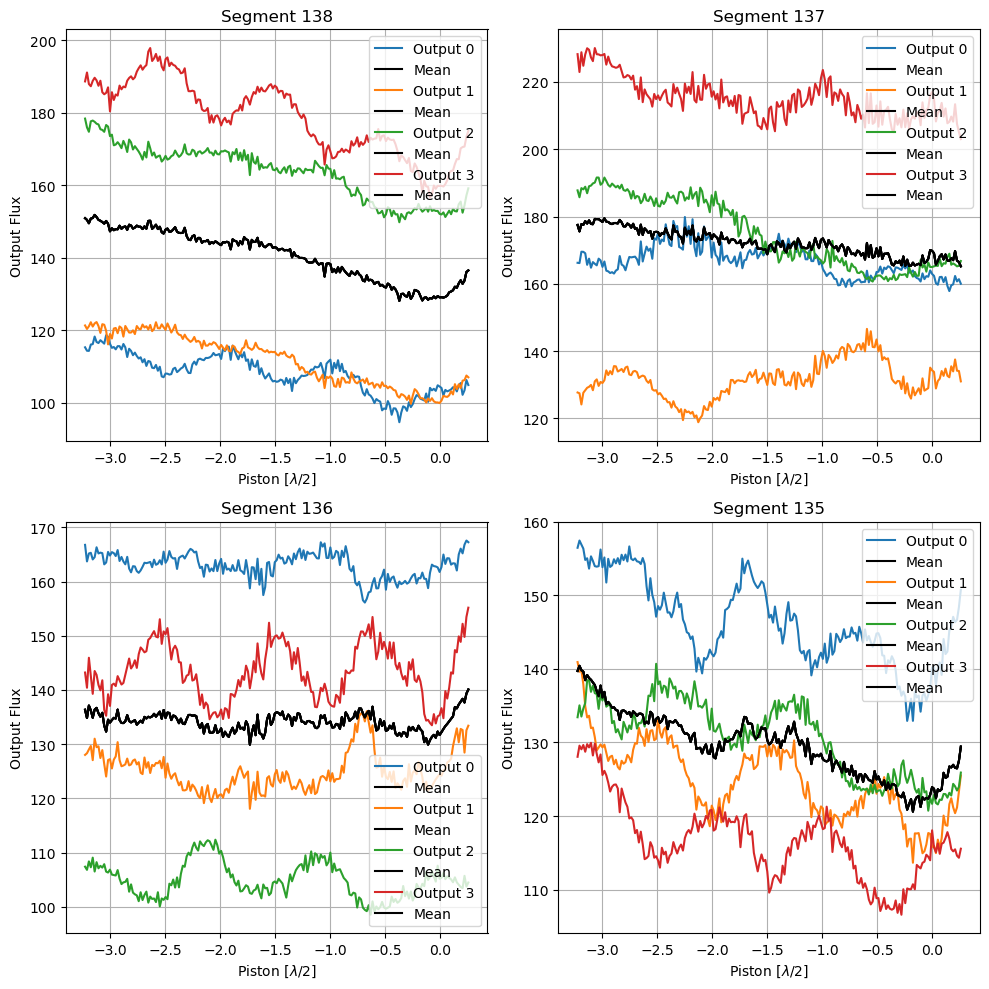

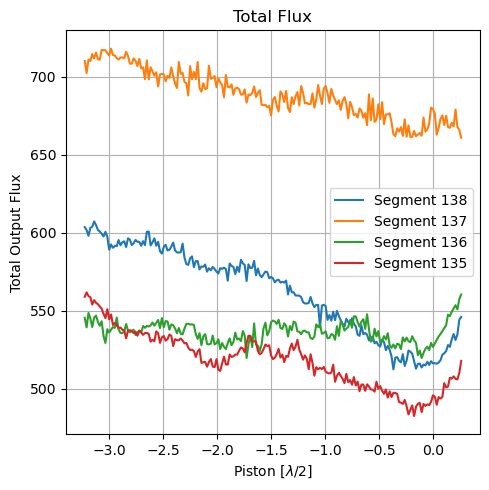

In [ ]:
# n_roi = 4
# avg_frames = 5
# piston_range = np.linspace(-2500, 200, 201)  # [nm]
# n_ch = len(inj_seg)
# res_single_scan = {}
# fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# axs = axs.flatten()
# colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# total_flux = []
# for beam in range(n_ch):
#     inj.off()
#     inj.set_balanced(beam)

#     ref_tip = dm[inj_seg[beam]].get_tip()
#     ref_tilt = dm[inj_seg[beam]].get_tilt()

#     outs = np.empty((len(piston_range), n_roi))
#     for p, opd in enumerate(piston_range):
#         dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
#         time.sleep(0.005)
#         outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

#     res_single_scan[inj_seg[beam]] = outs.copy()
#     total_flux.append(outs[:].sum(axis=1))

#     for o in range(n_roi):
#         axs[beam].plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
#         axs[beam].plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
#     axs[beam].set_title(f'Segment {inj_seg[beam]}')
#     axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
#     axs[beam].set_ylabel('Output Flux')
#     axs[beam].legend()
#     axs[beam].grid()


# fig.tight_layout()
# fig.savefig(path / 'singlebeam_scan_max.png')

# total_flux = np.array(total_flux)

# np.savez(path / 'monobeam_scan_balanced', flux=total_flux, piston=piston_range, lam=lam)

# fig, axs = plt.subplots(1, 1, figsize=(5, 5))

# for o in range(n_ch):
#     axs.plot(piston_range / (lam/2), total_flux[o], 
#              color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
# axs.set_title('Total Flux')
# axs.set_xlabel('Piston [$\lambda/2$]')
# axs.set_ylabel('Total Output Flux')
# axs.legend()
# axs.grid()
# fig.tight_layout()
# fig.savefig(path / 'singlebeam_scan_balanced_totalflux.png')

# inj.set_balanced()


## Max position

In [ ]:
n_roi = 4
avg_frames = 5
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
filename = 'crosstalk_dm_scan_max'

max_all_beams = scan_monobeam(inj.set_max, n_ch, n_roi, piston_range)
np.savez(path / filename, flux=max_all_beams, piston_range=piston_range, lam=lam)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for beam in range(n_ch):
    for o in range(n_roi):
        axs[beam].plot(piston_range / (lam/2), max_all_beams[beam, :, o], color=colors[o], linestyle='-', label=f'Output {o}')
        axs[beam].plot(piston_range / (lam/2), max_all_beams[beam].mean(1), color='k', linestyle='-', label=f'Mean')
    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()

fig.tight_layout()
fig.savefig(path / filename, format='png', dpi=150)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(n_ch):
    axs.plot(piston_range / (lam/2), max_all_beams[beam].sum(1), 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
filename2 = filename + '_totalflux.png'
fig.savefig(path / filename2, format='png', dpi=150)

inj.set_balanced()

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


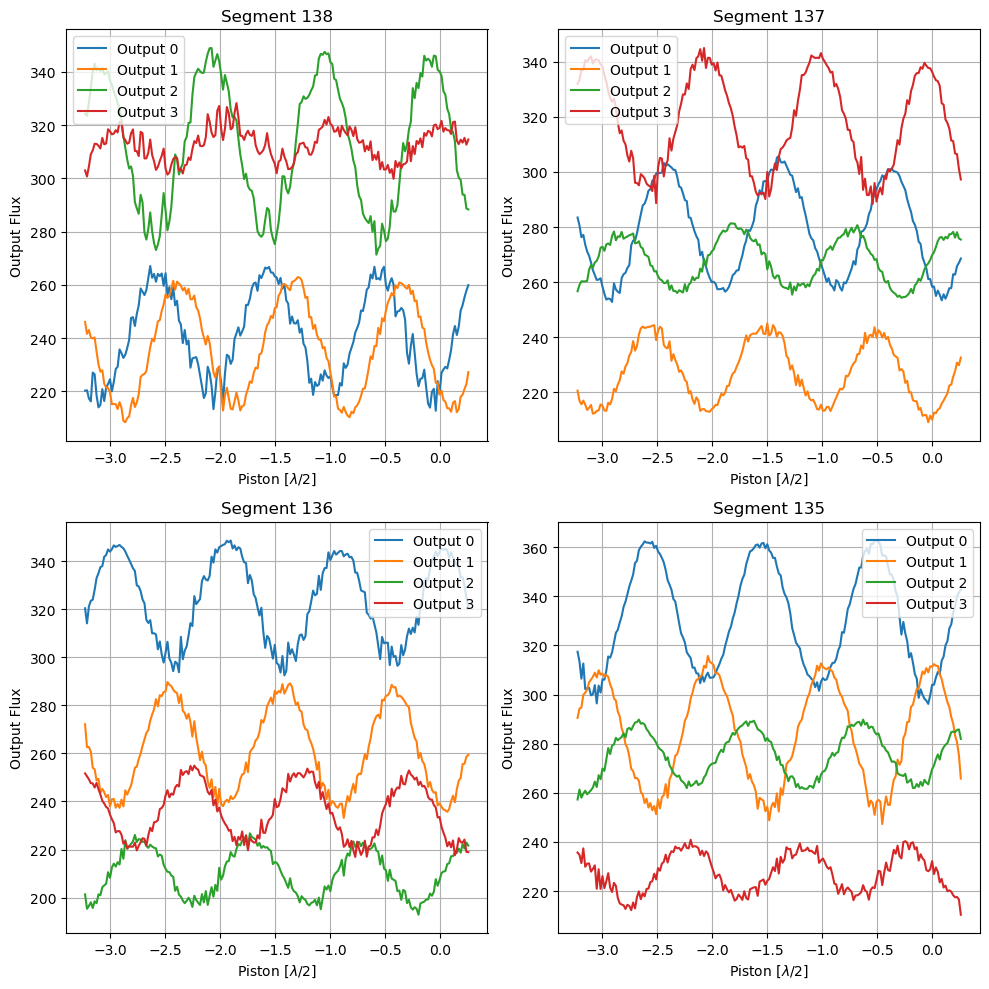

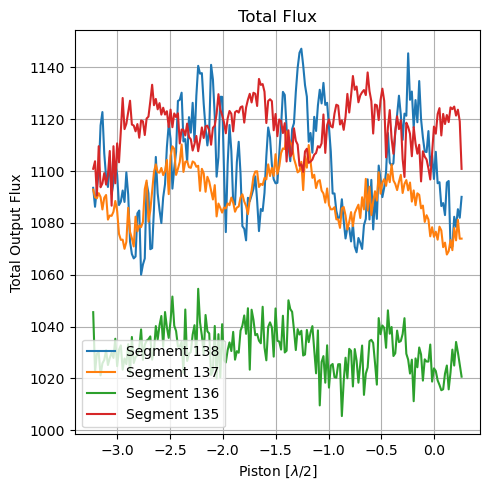

In [ ]:
# n_roi = 4
# piston_range = np.linspace(-2500, 200, 201)  # [nm]
# n_ch = len(inj_seg)
# res_single_scan = {}
# fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# axs = axs.flatten()
# colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
# avg_frames = 5

# total_flux = []
# for beam in range(n_ch):
#     inj.off()
#     inj.set_max(beam)

#     ref_tip = dm[inj_seg[beam]].get_tip()
#     ref_tilt = dm[inj_seg[beam]].get_tilt()

#     outs = np.empty((len(piston_range), n_roi))
#     for p, opd in enumerate(piston_range):
#         dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
#         time.sleep(0.005)
#         outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

#     res_single_scan[inj_seg[beam]] = outs.copy()
#     total_flux.append(outs[:].sum(axis=1))

#     for o in range(n_ch):
#         axs[beam].plot(piston_range / (lam / 2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

#     axs[beam].set_title(f'Segment {inj_seg[beam]}')
#     axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
#     axs[beam].set_ylabel('Output Flux')
#     axs[beam].legend()
#     axs[beam].grid()


# fig.tight_layout()
# fig.savefig(path / 'singlebeam_scan_max.png')

# total_flux = np.array(total_flux)
# fig, axs = plt.subplots(1, 1, figsize=(5, 5))

# for o in range(n_ch):
#     axs.plot(piston_range / (lam / 2), total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

# axs.set_title('Total Flux')
# axs.set_xlabel(r'Piston [$\lambda/2$]')
# axs.set_ylabel('Total Output Flux')
# axs.legend()
# axs.grid()
# fig.tight_layout()
# fig.savefig(path / 'singlebeam_scan_max_totalflux.png')

# inj.set_balanced()

# Physically blocked beam

Segment: 138
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])


KeyboardInterrupt: 

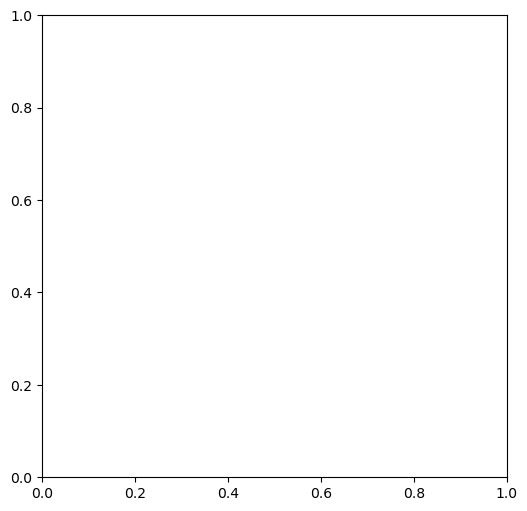

In [ ]:
n_roi = 4
avg_frames = 10
piston_range = np.linspace(-2500, 200, 201)  # [nm]
beam = 0
seg = inj_seg[beam]
print('Segment:', seg)
filename = f'crosstalk_dm_seg{seg}_scan_balanced'


inj.off()
inj.set_balanced(beam)

ref_tip = dm[inj_seg[beam]].get_tip()
ref_tilt = dm[inj_seg[beam]].get_tilt()

outs = np.empty((len(piston_range), n_roi))
for p, opd in enumerate(piston_range):
    dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
    outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]

np.savez(path / filename, flux=outs, piston_range=piston_range, lam=lam)

fig, axs = plt.subplots(1, 1, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for o in range(n_roi):
    axs.plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
    axs.plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
axs.set_title(f'Segment {inj_seg[beam]}')
axs.set_xlabel(r'Piston [$\lambda/2$]')
axs.set_ylabel('Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / filename, format='png', dpi=150)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(1):
    axs.plot(piston_range / (lam/2), outs.sum(1), 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
filename2 = filename + '_totalflux'
fig.savefig(path / filename2, format='png', dpi=150)

inj.set_balanced()


# Phase shiter crosstalks

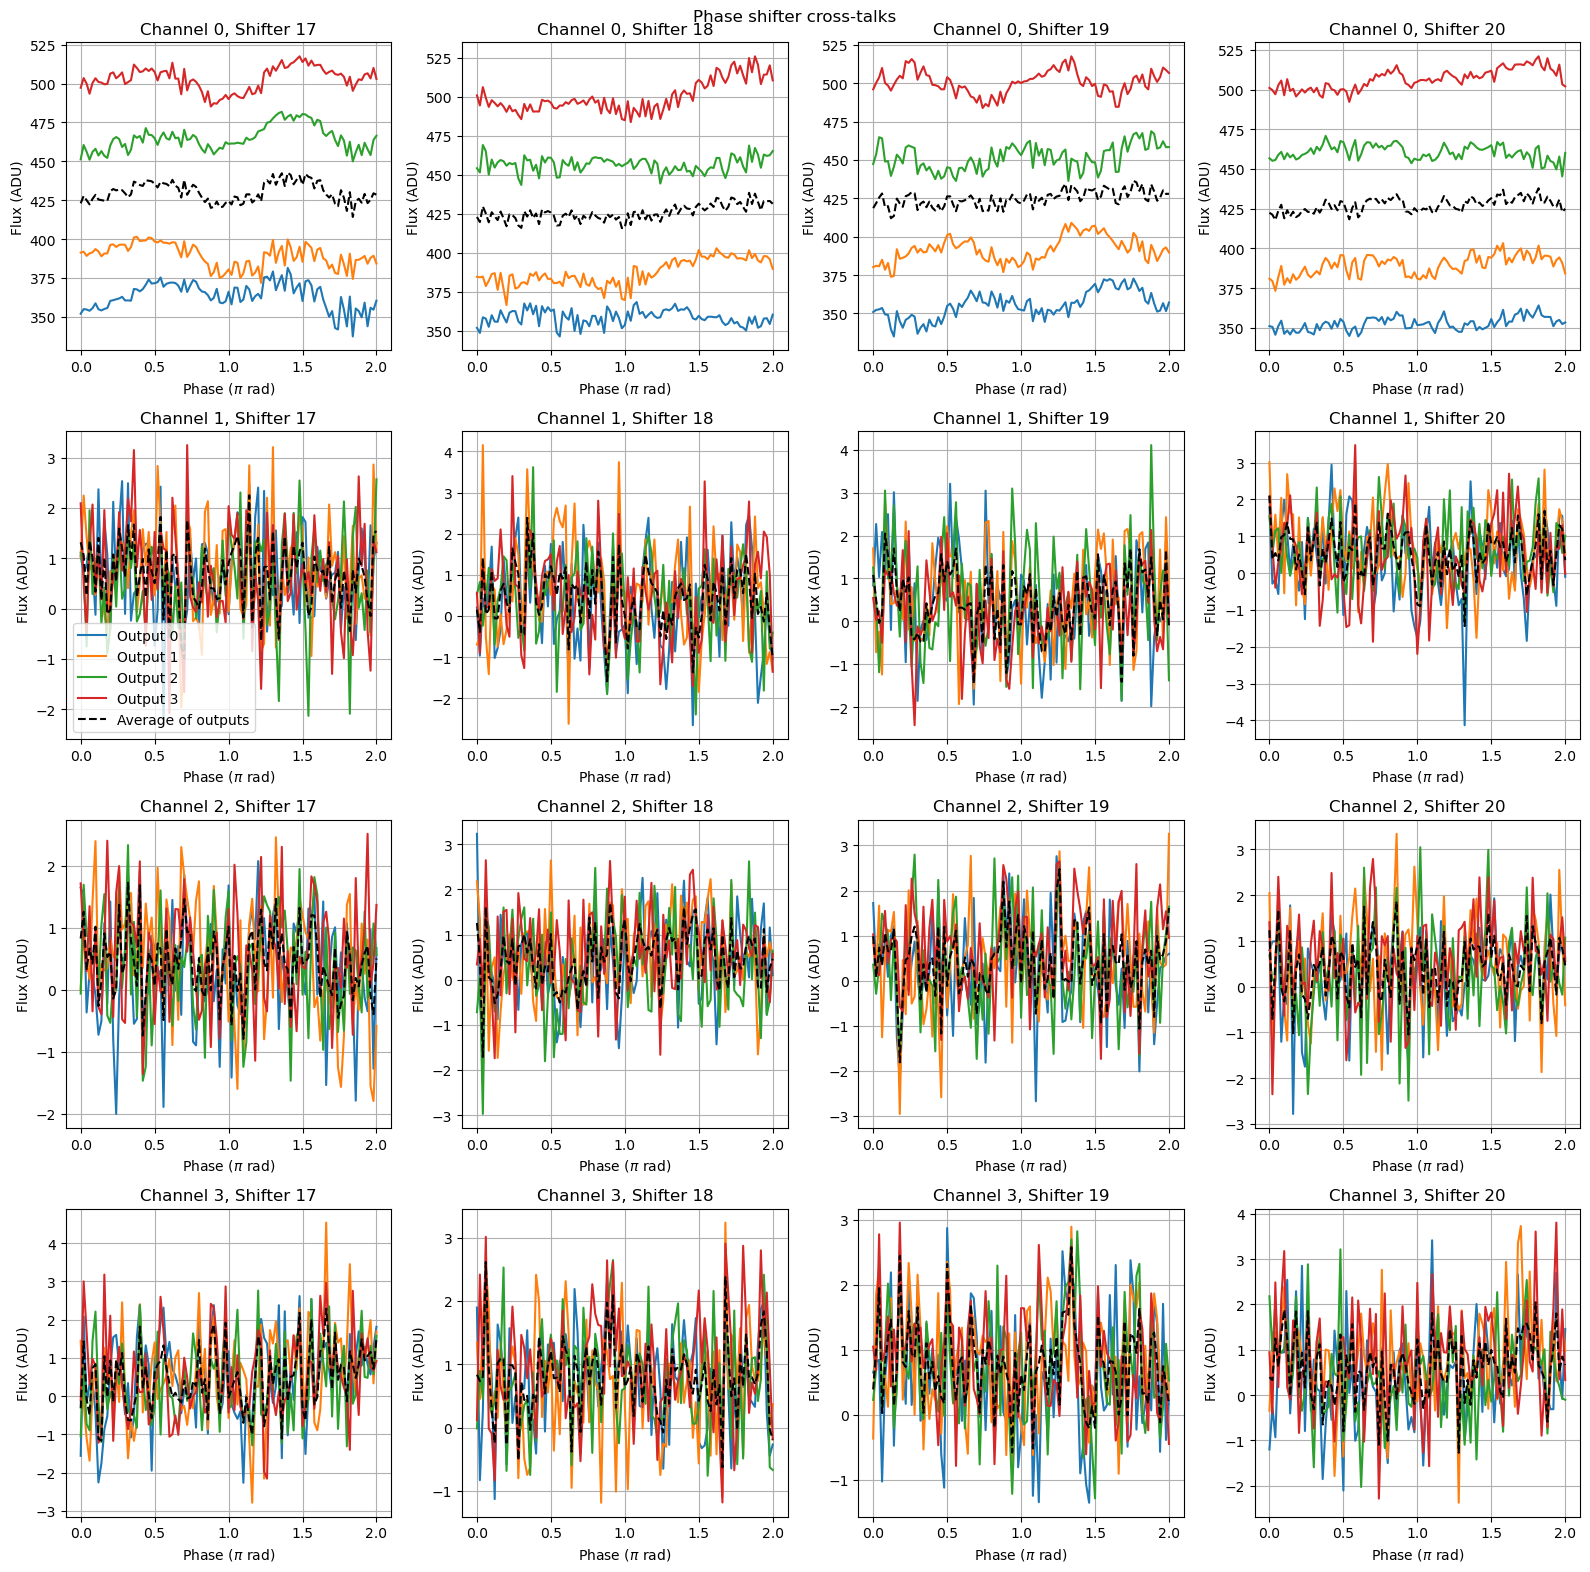

In [ ]:
channels = [0, 1, 2, 3]
power_ramp = np.linspace(0, 1., 101)
n_roi = 4
beam = 0
seg = inj_seg[beam]
filename = f'crosstalks_phase_shifter_seg{seg}'

chip.turn_off()

data = []
for ch in channels:
    inj.off()
    inj.set_balanced(ch)
    flx_shifter = []
    for shifter in chip.shifters:
        print('Scanning shifter:', shifter.channel)
        flux = []
        for p in tqdm(power_ramp):
            shifter.set_phase(p)
            flx = cam.get_outputs(flux_mode='mean', stack=5, crop_mode='centers')[:n_roi]
            flux.append(flx)
        flx_shifter.append(flux)
        shifter.turn_off()
    data.append(flx_shifter)

data = np.array(data) # shape (n_channels, n_shifters, n_phases, n_outputs)
print(data.shape)
np.savez(path / filename, flux=data, power_ramp=power_ramp)

fig, axs = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Phase shifter cross-talks')
for ch in channels:
    for shifter_idx, shifter in enumerate(chip.shifters):
        axs[ch, shifter_idx].plot(power_ramp, data[ch, shifter_idx])
        axs[ch, shifter_idx].plot(power_ramp, data[ch, shifter_idx].mean(-1), '--', c='k')
        axs[ch, shifter_idx].set_title(f'Channel {ch}, Shifter {shifter.channel}')
        axs[ch, shifter_idx].set_xlabel(r'Power (W)')
        axs[ch, shifter_idx].set_ylabel('Flux (ADU)')
        axs[ch, shifter_idx].grid(True)
        if ch == 1 and shifter_idx == 0:
            axs[ch, shifter_idx].legend([f'Output {i}' for i in range(n_roi)]+['Average of outputs'], loc='best')
fig.tight_layout()
fig.savefig(path / filename, format='png', dpi=150)

        

# The end

In [135]:
print('Path is', path)

inj.zero()

Path is /mnt/disk1/archive/2026-06-11_b9ed59a/3_dispersed
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [136]:
phobos.XPOW().turn_off()